## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
from unet import Unet 
from os import listdir,mkdir
import matplotlib.pyplot as plt
from warnings import filterwarnings
from datetime import date, datetime
from monai.data import DataLoader,Dataset
from os.path import join,exists,expanduser
from pytorch_lightning.loggers import CSVLogger
from sklearn.model_selection import train_test_split
from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from Utils.plotting_functions import (plot_single_trace_fig, wigle_plot)
from torch import (from_numpy,device, set_float32_matmul_precision,argmax)

In [2]:
set_float32_matmul_precision('high')
filterwarnings('ignore')

## Loading Data and Processing

In [3]:
train_dir = 'Data/'
traces_arr = np.load(join(train_dir,'dataset_train.npz'))['arr_0']
labels_arr = np.load(join(train_dir,'dataset_train.npz'))['arr_1']

print(f'Input Shape: {traces_arr.shape}')
print(f'Labels Shape: {labels_arr.shape}')

traces_arr_plot = traces_arr.copy()
labels_arr_plot = labels_arr.copy()

Input Shape: (19560, 1001)
Labels Shape: (19560, 1001)


## Transforming to Model Torch

In [4]:
traces_arr = from_numpy(traces_arr[:,None,:])
labels_arr = from_numpy(labels_arr[:,None,:])

print(f'Input shape: {traces_arr.shape} and input type: {type(traces_arr)}')
print(f'Input shape: {labels_arr.shape} and input type: {type(labels_arr)}')

Input shape: torch.Size([19560, 1, 1001]) and input type: <class 'torch.Tensor'>
Input shape: torch.Size([19560, 1, 1001]) and input type: <class 'torch.Tensor'>


## Holdout Validation

In [5]:
x_train, x_test, y_train, y_test = train_test_split(traces_arr,labels_arr,
                                                    test_size=1/4)
print(f'Train Dataset: {x_train.shape}')
print(f'Test Dataset:  {x_test.shape}')

Train Dataset: torch.Size([14670, 1, 1001])
Test Dataset:  torch.Size([4890, 1, 1001])


## Putting the data into dictionary

In [6]:
train_files = [{'x':img, 'y':lbl} for img,lbl in zip(x_train,y_train)]
val_files = [{'x':img, 'y':lbl} for img,lbl in zip(x_test,y_test)]

## Loading DataLoader

In [7]:
#loading dataset on dataloaders
train_ds = Dataset(data=train_files, transform = None)
train_loader = DataLoader(train_ds,batch_size=500, shuffle=True,
                          num_workers = 16, pin_memory=False, drop_last = False)

val_ds = Dataset(data=val_files, transform = None)
val_loader = DataLoader(val_ds,batch_size=500, shuffle=False,
                        num_workers = 16,pin_memory=False, drop_last = False)

## Creating Directory to Save Files

In [8]:
model_number = 0
today = date.today()
dirpath = expanduser('Models_Saved/')


if not exists(join(dirpath,f'Model_{int(model_number)}_Date_{today}')):
        mkdir(join(dirpath,f'Model_{int(model_number)}_Date_{today}'))
else:
    while exists(join(dirpath,f'Model_{int(model_number)}_Date_{today}')) is True:
        model_number += 1
        if not exists (join(dirpath,f'Model_{int(model_number)}_Date_{today}')):
            mkdir(join(dirpath,f'Model_{int(model_number)}_Date_{today}'))
            break
            
model_dir = join(dirpath,f'Model_{int(model_number)}_Date_{today}')
print('The directory was created with sucess!!')
print(f'Directory:{model_dir}')

The directory was created with sucess!!
Directory:Models_Saved/Model_0_Date_2025-08-07


## Unet

In [9]:
model = Unet()
early_stopping = EarlyStopping(monitor='Valid_acc',
                               min_delta = 0.001,mode='max',
                               patience = 10, verbose = False,
                              check_on_train_epoch_end = False)
model_checkpoint =  ModelCheckpoint(save_top_k = 1,
                                    monitor = 'Valid_acc',
                                    mode='max',
                                    dirpath = model_dir,
                                    filename ='model',
                                   save_on_train_epoch_end = True)
logger = CSVLogger(save_dir = model_dir,
                         name=f'model_logs', version=f'logs_{datetime.today().strftime("%Y-%m-%d")}')

trainer = Trainer(max_epochs=20000, 
                    accelerator='gpu', devices=[0,1,2],
                    callbacks = [early_stopping, model_checkpoint],
                    log_every_n_steps=34,
                    logger=logger)
trainer.fit(model,train_loader,val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/3
Initializing distributed: GLOBAL_RANK: 1, MEMBER: 2/3
Initializing distributed: GLOBAL_RANK: 2, MEMBER: 3/3
----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 3 processes
----------------------------------------------------------------------------------------------------

LOCAL_RANK: 2 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
LOCAL_RANK: 1 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name      | Type            | Params | Mode 
------------------------------------------------------
0 | model     | Sequential      | 1.1 M  | train
1 | loss      | DiceCELoss      | 0      | train
2 | train_acc | BinaryAccuracy  | 0      | train
3 | valid_acc | BinaryAccuracy  | 

Sanity Checking: |                                                                      | 0/? [00:00<?, ?it/s]

Training: |                                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                                           | 0/? [00:00<?, ?it/s]

...

Validation: |                                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                                           | 0/? [00:00<?, ?it/s]

Validation: |                                                                           | 0/? [00:00<?, ?it/s]

## Graph

In [10]:
metrics = pd.read_csv(join(logger.log_dir,'metrics.csv'))
metrics = metrics.interpolate()

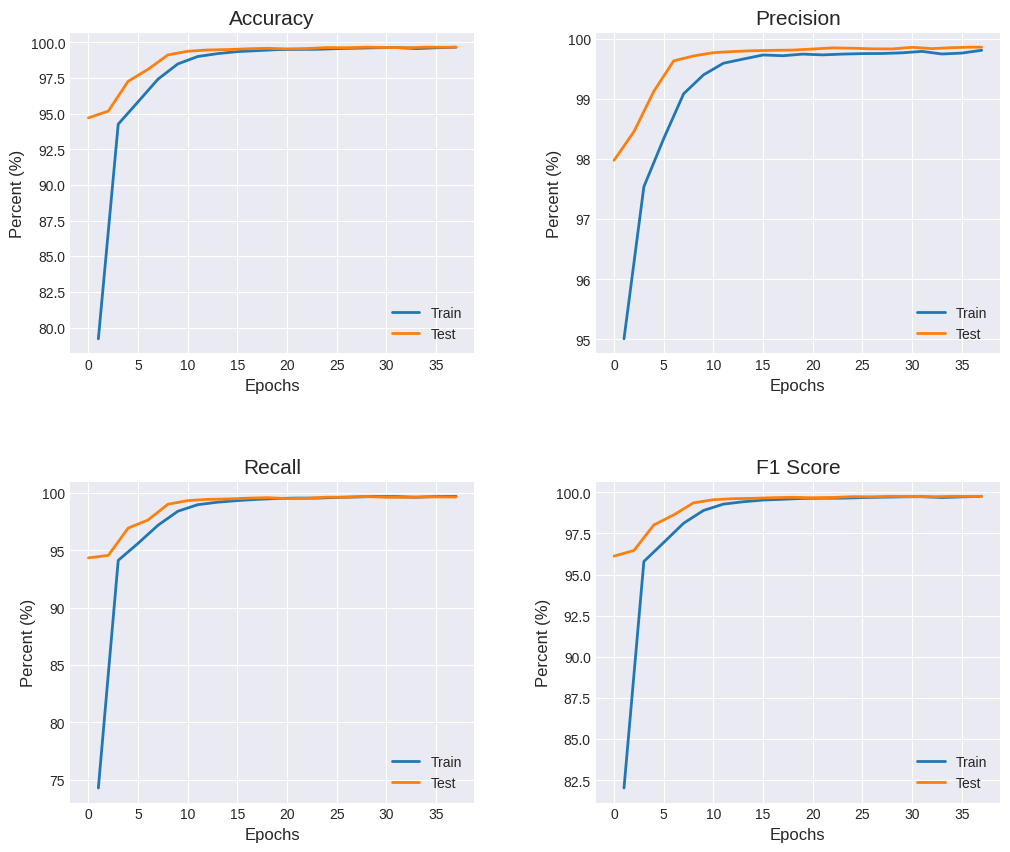

In [12]:
cmap_list = [names for names in plt.style.available]

plt.style.use('seaborn-v0_8-darkgrid')

fig,axis = plt.subplots(nrows=2, ncols=2, figsize=(12,10))
plt.subplots_adjust(wspace=.3, hspace=.4)

# Linecolors
train_color = '#1f77b4'
valid_color = '#ff7f0e'
line_width = 2.5

axis[0,0].plot(metrics['Train_acc']*100, linewidth=2)
axis[0,0].plot(metrics['Valid_acc']*100, linewidth=2)
axis[0,0].set_title('Accuracy', fontsize=15)
axis[0,0].set_xlabel('Epochs', fontsize=12)
axis[0,0].set_ylabel('Percent (%)', fontsize=12)
axis[0,0].legend(['Train','Test'], loc='lower right')
axis[0,0].ticklabel_format(useOffset=False)

axis[0,1].plot(metrics['Precision']*100, linewidth=2)
axis[0,1].plot(metrics['Val_Precision']*100, linewidth=2)
axis[0,1].set_title('Precision', fontsize=15)
axis[0,1].set_xlabel('Epochs', fontsize=12)
axis[0,1].set_ylabel('Percent (%)', fontsize=12)
axis[0,1].legend(['Train','Test'], loc='lower right')
axis[0,1].ticklabel_format(useOffset=False)

axis[1,0].plot(metrics['Recall']*100, linewidth=2)
axis[1,0].plot(metrics['Val_Recall']*100, linewidth=2)
axis[1,0].set_title('Recall', fontsize=15)
axis[1,0].set_xlabel('Epochs', fontsize=12)
axis[1,0].set_ylabel('Percent (%)', fontsize=12)
axis[1,0].legend(['Train','Test'], loc='lower right')
axis[1,0].ticklabel_format(useOffset=False)

axis[1,1].plot(metrics['F1_Score']*100, linewidth=2)
axis[1,1].plot(metrics['Val_F1_Score']*100, linewidth=2)
axis[1,1].set_title('F1 Score', fontsize=15)
axis[1,1].set_xlabel('Epochs', fontsize=12)
axis[1,1].set_ylabel('Percent (%)', fontsize=12)
axis[1,1].legend(['Train','Test'], loc='lower right')
axis[1,1].ticklabel_format(useOffset=False)

# plt.savefig('figures/metrics.png', dpi=100, format='png')
plt.show()

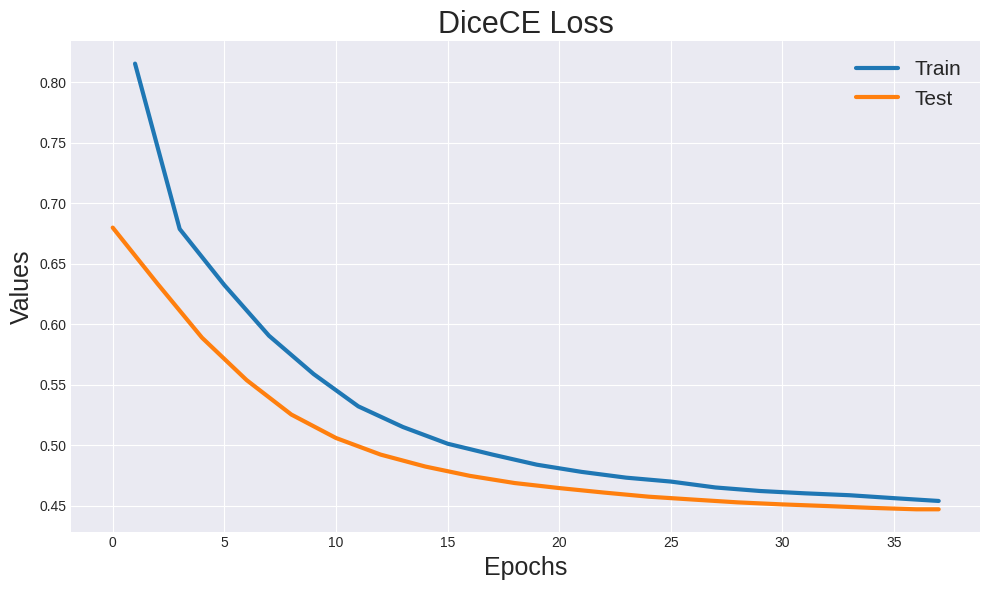

In [13]:
plt.figure(figsize=(10,6))
plt.plot(metrics['Train_loss'], linewidth=3)
plt.plot(metrics['Val_loss'], linewidth=3)
plt.title('DiceCE Loss', fontsize=22)
plt.xlabel('Epochs',fontsize=18)
plt.ylabel('Values', fontsize=18)
plt.legend(['Train','Test'], fontsize=15)
plt.tight_layout()

# plt.savefig('figures/loss.png', dpi=100, format='png')

## Loading Prediction Data

In [14]:
v_min,v_max= 1700,6000
t_min,t_max, t0 = 0.004, 4.004, 2
t = np.arange(0.004,1001*0.004,0.004)
alpha = (v_max-v_min)/(t_max-t_min)
v = alpha*t+v_min

#Loading the Npz file
pred_dir = 'Data/'
pred_dataset = np.load(join(pred_dir,'dataset_predict.npz'))['arr_0']
pred_data_plot = pred_dataset
pred_dataset = pred_dataset*((v**2)*t)/((v[np.where(t==t0)]**2)*t0).T

#Normalizing Data
pred_dataset.std(axis=1).shape
pred_dataset = (pred_dataset.T/pred_dataset.std(axis=1)).T
#Putting on Torch format
pred_dataset = from_numpy(np.float32(pred_dataset[:,None,:]))
# pred_dataset = from_numpy(np.float32(pred_dataset))
print(f'Prediction Data Shape: {pred_dataset.shape}')
print(f'Prediciton Data Type:{pred_dataset.dtype}')

Prediction Data Shape: torch.Size([237687, 1, 1001])
Prediciton Data Type:torch.float32


## Creating a DataLoader

In [15]:
#creating a dataloader for prediction
pred_ds = Dataset(data=pred_dataset, transform = None)
pred_loader = DataLoader(pred_ds,batch_size=1000, shuffle=False,
                          num_workers = 16, pin_memory=False, drop_last = False)

## Selecting Model for Prediction

In [16]:
model_file = [join(model_dir,file) for file in listdir(model_dir) if file.endswith('ckpt')]
model_file

['Models_Saved/Model_0_Date_2025-08-07/model.ckpt']

In [17]:
#predicting with the model
modelo = Unet.load_from_checkpoint(model_file[0])
trainer_pred = Trainer(accelerator='gpu', devices=[3]) 
predict_step = trainer_pred.predict(modelo, pred_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Predicting: |                                                                           | 0/? [00:00<?, ?it/s]

In [18]:
#joining all prediction images on a unique list and transform on tensor
total_predictions = []

for pred_loader in predict_step:
    for pred_tns in pred_loader:
        total_predictions.append(np.asarray(pred_tns))
        
print(f'Predictions Size: {len(total_predictions)}')
# total_pred = np.asarray(total_predictions).reshape(237687, 1001).copy()
total_pred = np.asarray(total_predictions)
total_pred=np.where(total_pred<0.5,0,1)

Predictions Size: 237687


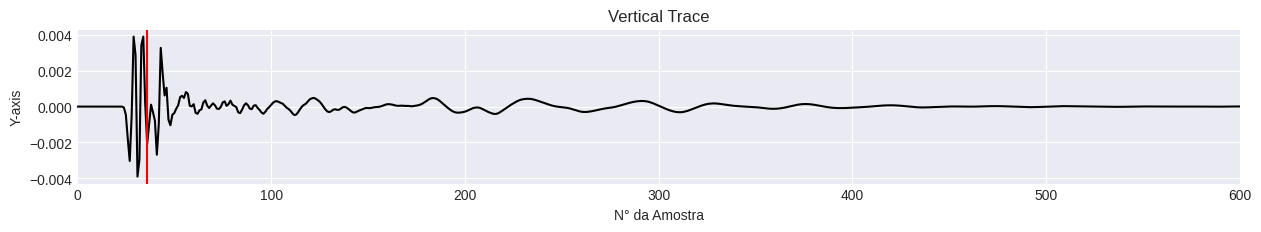

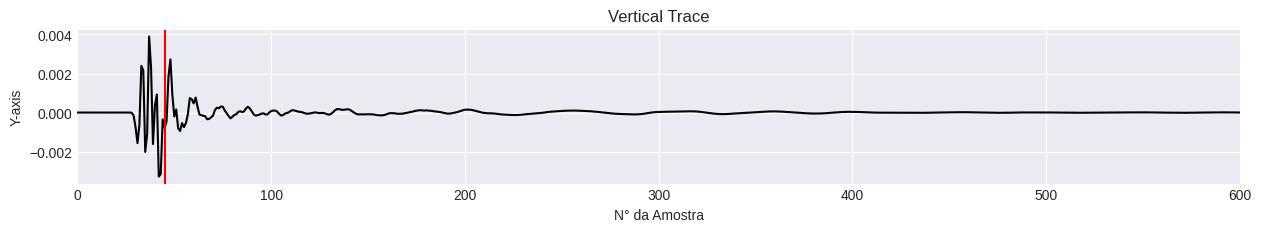

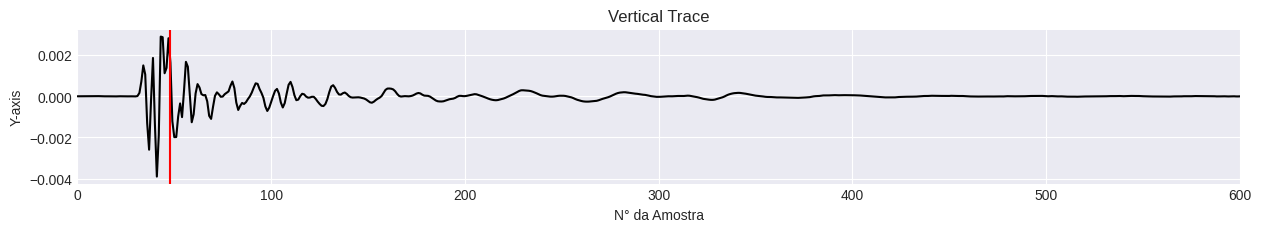

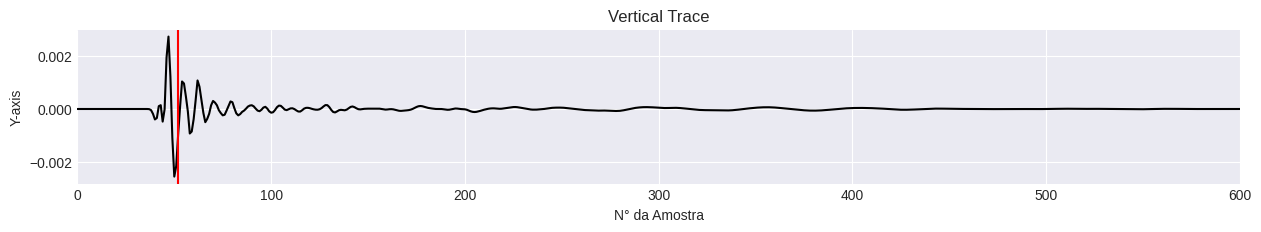

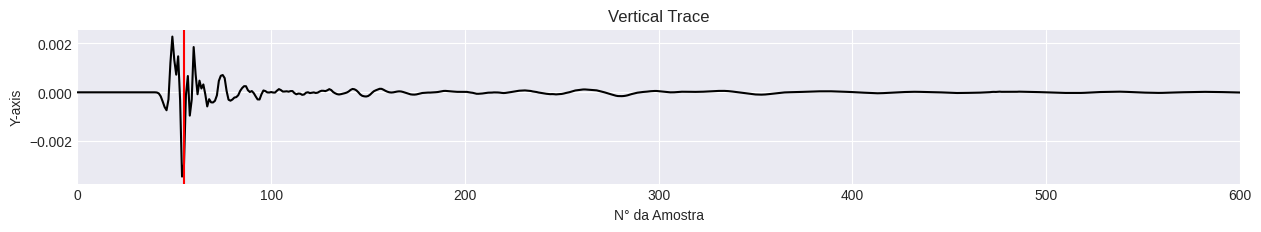

In [23]:
for i in range(0,5):#80000,80015
    fig,ax = plt.subplots(figsize=(15,2))
    
    ax.plot(pred_data_plot[i], color='black')
    
    ax.axvline(x=np.argmax(total_pred[i]), color='red')
    #ax.axvline(x=np.argmax(labels_arr[i]), color='green') #label
    
    ax.set_xlim([0,600])
    ax.set_xlabel('N° da Amostra')
    ax.set_ylabel('Y-axis')
    ax.set_title('Vertical Trace')
    
    plt.show()
#     fig.savefig(f'amostra_{i}.png', transparent=False)